# Novel View Synthesis: Rendering Predicted Gaussians from New Camera Angles

This notebook is part of the **W14 3D Gaussian Splatting series**. It picks up where [**[NB 01](https://github.com/artifocial/tutorials/blob/main/2026-W14/01_image_to_gaussians.ipynb): Image-to-Gaussians**](01_image_to_gaussians.ipynb) left off.

**Goal:** Take the predicted Gaussians from NB 01's image→encoder→decoder→render pipeline and systematically render them from novel camera angles. We'll evaluate how reconstruction quality degrades as we move away from the original training viewpoint.

This is the companion notebook to [**The Image-to-3D Landscape**](https://artifocial.com/blog/image-to-3d-landscape-2026-apr-05).

**Key Concepts:**
- Camera orbit generation and pose parameterization
- Systematic evaluation of view-dependent errors
- Smooth camera paths and temporal consistency
- Failure modes of single-image 3D reconstruction

**Difficulty:** Intermediate | **CPU Runtime:** ~3–5 min

## Setup

In [1]:
import shutil
import subprocess
import sys

# uv-first: use uv if available, fall back to pip
if shutil.which("uv"):
    subprocess.check_call(
        ["uv", "pip", "install", "--quiet", "--system", "numpy", "matplotlib"]
    )
else:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "numpy", "matplotlib"]
    )

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
print("Setup complete! NumPy and Matplotlib loaded.")
print(f"NumPy version: {np.__version__}")

Setup complete! NumPy and Matplotlib loaded.
NumPy version: 2.2.6


## Part 1: Scene Setup & Gaussian Prediction Recap

We'll reuse the synthetic 3D scene, camera model, and rendering function from [NB 01](https://artifocial.com/notebooks/2026-W14/01_image_to_gaussians). This section reconstructs the key pieces so [NB 02](https://github.com/artifocial/tutorials/blob/main/2026-W14/02_novel_view_synthesis.ipynb) is self-contained.

In [2]:
def create_synthetic_scene(num_gaussians=40):
    """
    Create a synthetic 3D scene as a collection of Gaussian parameters.

    Each Gaussian: (x, y, z, sx, sy, sz, qx, qy, qz, qw, opacity, r, g, b)
    Total: 14 parameters per Gaussian.
    """
    gaussians = []

    # Red sphere (center-left)
    center_red = np.array([-2.0, 0.0, 0.0])
    for _ in range(10):
        pos = center_red + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])  # identity rotation
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([1.0, 0.2, 0.2])  # red
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Green sphere (center-right)
    center_green = np.array([2.0, 0.0, 0.0])
    for _ in range(10):
        pos = center_green + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([0.2, 1.0, 0.2])  # green
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Blue sphere (above)
    center_blue = np.array([0.0, 2.0, 0.0])
    for _ in range(10):
        pos = center_blue + np.random.normal(0, 0.3, 3)
        scale = np.abs(np.random.normal(0.3, 0.05, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([0.2, 0.2, 1.0])  # blue
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    # Yellow cluster (below)
    center_yellow = np.array([0.0, -2.0, 0.0])
    for _ in range(10):
        pos = center_yellow + np.random.normal(0, 0.4, 3)
        scale = np.abs(np.random.normal(0.35, 0.06, 3))
        quat = np.array([0, 0, 0, 1])
        opacity = np.random.uniform(0.7, 1.0)
        color = np.array([1.0, 1.0, 0.2])  # yellow
        gaussians.append(np.concatenate([pos, scale, quat, [opacity], color]))

    return np.array(gaussians)


# Create the ground-truth scene
ground_truth_gaussians = create_synthetic_scene(40)
print(f"✓ Scene created: {ground_truth_gaussians.shape[0]} Gaussians")
print(
    f"  Each Gaussian has 14 parameters: (x,y,z, sx,sy,sz, qx,qy,qz,qw, opacity, r,g,b)"
)

✓ Scene created: 40 Gaussians
  Each Gaussian has 14 parameters: (x,y,z, sx,sy,sz, qx,qy,qz,qw, opacity, r,g,b)


## Camera Model

The **PinholeCamera** class handles projection, and we use Euler angles to create rotation matrices.

In [3]:
class PinholeCamera:
    def __init__(self, focal=100.0, cx=32.0, cy=32.0, width=64, height=64):
        """
        Simple pinhole camera model.
        focal: focal length in pixels
        cx, cy: principal point (image center)
        width, height: image resolution
        """
        self.focal = focal
        self.cx = cx
        self.cy = cy
        self.width = width
        self.height = height
        self.K = np.array([[focal, 0, cx], [0, focal, cy], [0, 0, 1]])

    def project(self, points_world, R, t):
        """
        Project 3D world points to 2D image coordinates.

        Args:
            points_world: (N, 3) array of 3D points
            R: (3, 3) rotation matrix (world to camera)
            t: (3,) translation vector (world to camera)

        Returns:
            points_2d: (N, 2) image coordinates (x, y)
            depths: (N,) depth in camera frame (for ordering)
        """
        # Transform to camera frame
        points_cam = (R @ points_world.T).T + t[np.newaxis, :]

        # Project via K
        proj = (self.K @ points_cam.T).T

        # Normalize by depth
        x = proj[:, 0] / (proj[:, 2] + 1e-8)
        y = proj[:, 1] / (proj[:, 2] + 1e-8)

        points_2d = np.stack([x, y], axis=1)
        depths = points_cam[:, 2]

        return points_2d, depths

    @staticmethod
    def rotation_matrix(theta_x, theta_y, theta_z):
        """Create rotation matrix from Euler angles (in radians)."""
        Rx = np.array(
            [
                [1, 0, 0],
                [0, np.cos(theta_x), -np.sin(theta_x)],
                [0, np.sin(theta_x), np.cos(theta_x)],
            ]
        )
        Ry = np.array(
            [
                [np.cos(theta_y), 0, np.sin(theta_y)],
                [0, 1, 0],
                [-np.sin(theta_y), 0, np.cos(theta_y)],
            ]
        )
        Rz = np.array(
            [
                [np.cos(theta_z), -np.sin(theta_z), 0],
                [np.sin(theta_z), np.cos(theta_z), 0],
                [0, 0, 1],
            ]
        )
        return Rz @ Ry @ Rx


# Create camera instance
camera = PinholeCamera(focal=100.0, cx=32.0, cy=32.0, width=64, height=64)
print(
    f"✓ Camera created (focal={camera.focal}, resolution={camera.width}x{camera.height})"
)

✓ Camera created (focal=100.0, resolution=64x64)


## Gaussian Rendering

This is the core rendering function using the painter's algorithm. Gaussians are sorted by depth and composited back-to-front.

In [4]:
def render_gaussians(gaussians, camera, R, t, resolution=64):
    """
    Render Gaussians from a given camera pose.

    Args:
        gaussians: (N, 14) array of Gaussian parameters
        camera: PinholeCamera instance
        R: (3, 3) rotation matrix (world to camera)
        t: (3,) translation vector
        resolution: output image resolution

    Returns:
        image: (H, W, 3) RGB image
    """
    H, W = resolution, resolution
    image = np.ones((H, W, 3))  # white background

    # Extract centers and colors from gaussians
    centers = gaussians[:, :3]
    colors = gaussians[:, 11:14]
    opacities = gaussians[:, 10:11]
    scales = gaussians[:, 3:6]

    # Project to 2D
    points_2d, depths = camera.project(centers, R, t)

    # Sort by depth (painter's algorithm)
    depth_order = np.argsort(-depths)

    # Render each Gaussian in back-to-front order
    for idx in depth_order:
        x, y = points_2d[idx]
        color = colors[idx]
        opacity = opacities[idx, 0]
        scale = scales[idx]

        # Gaussian extent (2-sigma)
        sigma = np.mean(scale) * 2
        radius = int(np.ceil(sigma * 2))

        # Create a Gaussian blob
        xi, yi = int(np.round(x)), int(np.round(y))

        # Clip to image bounds
        y_min = max(0, yi - radius)
        y_max = min(H, yi + radius + 1)
        x_min = max(0, xi - radius)
        x_max = min(W, xi + radius + 1)

        if y_max <= y_min or x_max <= x_min:
            continue

        # Compute 2D Gaussian weights
        yy, xx = np.meshgrid(
            np.arange(y_min, y_max, dtype=np.float32),
            np.arange(x_min, x_max, dtype=np.float32),
            indexing="ij",
        )
        dist_sq = ((xx - x) ** 2 + (yy - y) ** 2) / (sigma**2 + 1e-8)
        weights = np.exp(-dist_sq)

        # Alpha blend
        alpha = weights * opacity
        image[y_min:y_max, x_min:x_max] *= 1 - alpha[:, :, np.newaxis]
        image[y_min:y_max, x_min:x_max] += (
            alpha[:, :, np.newaxis] * color[np.newaxis, np.newaxis, :]
        )

    return np.clip(image, 0, 1)


print("✓ render_gaussians function ready")

✓ render_gaussians function ready


## Create Ground-Truth Baseline Views

First, let's render the ground-truth Gaussians from a simple orbit to establish a baseline.

In [5]:
def create_camera_poses(num_views=4, orbit_radius=5.0, height=2.0):
    """
    Create multiple camera poses arranged in a circle around the origin.

    Args:
        num_views: number of views to generate
        orbit_radius: distance from the origin (in world units)
        height: camera height (Y coordinate)

    Returns:
        list of (R, t) tuples for each view
    """
    poses = []
    for i in range(num_views):
        angle = 2 * np.pi * i / num_views

        # Camera positioned on a circle around the scene
        cam_x = orbit_radius * np.cos(angle)
        cam_z = orbit_radius * np.sin(angle)
        cam_y = height

        # Look at origin
        cam_pos = np.array([cam_x, cam_y, cam_z])
        look_at = np.array([0.0, 0.0, 0.0])
        up = np.array([0.0, 1.0, 0.0])

        # Construct world-to-camera transformation using look-at
        forward = (look_at - cam_pos) / (np.linalg.norm(look_at - cam_pos) + 1e-8)
        right = np.cross(forward, up)
        right = right / (np.linalg.norm(right) + 1e-8)
        up_corrected = np.cross(right, forward)
        up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

        # World-to-camera rotation (transpose of camera-to-world)
        R = np.stack([-right, up_corrected, -forward], axis=1).T

        # Translation
        t = R @ (-cam_pos)

        poses.append((R, t))

    return poses


# Create camera orbit
camera_poses_orbit = create_camera_poses(num_views=4, orbit_radius=5.0, height=2.0)
print(f"✓ Created {len(camera_poses_orbit)} camera poses in circular orbit")

# Render ground-truth from all orbit views
print("Rendering ground truth views...")
ground_truth_images = []
for i, (R, t) in enumerate(camera_poses_orbit):
    img = render_gaussians(ground_truth_gaussians, camera, R, t, resolution=64)
    ground_truth_images.append(img)
    print(f"  View {i}: rendered")

print(f"✓ Ground truth images shape: {ground_truth_images[0].shape}")

✓ Created 4 camera poses in circular orbit
Rendering ground truth views...
  View 0: rendered
  View 1: rendered
  View 2: rendered
  View 3: rendered
✓ Ground truth images shape: (64, 64, 3)


## Quick Ground-Truth Visualization

Display the rendered ground-truth views to confirm they look reasonable.

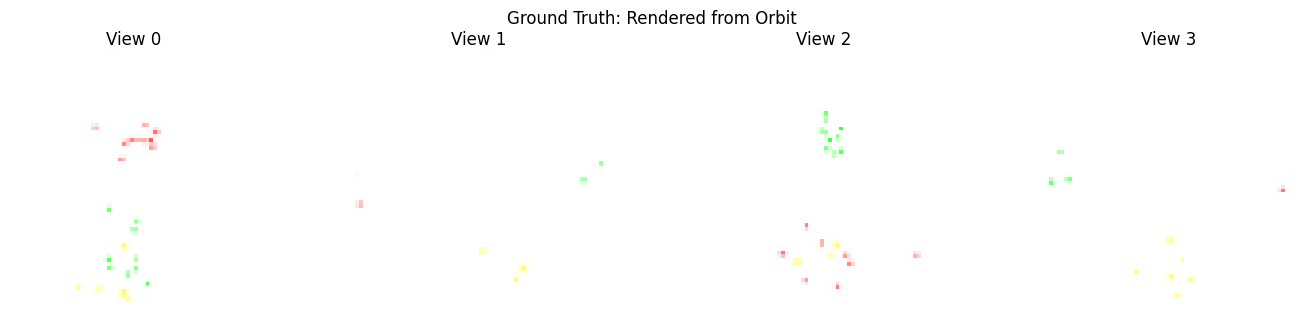

Ground-truth orbit views ready.


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, img in enumerate(ground_truth_images):
    axes[i].imshow(img)
    axes[i].set_title(f"View {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.suptitle("Ground Truth: Rendered from Orbit", fontsize=12, y=1.02)
plt.show()

print("Ground-truth orbit views ready.")

## Part 2: Camera Orbit Generation

Now we'll generate a more detailed orbit with many views, and also create random camera poses for stress testing.

In [7]:
# Generate a dense orbit for novel view synthesis evaluation
camera_poses_dense = create_camera_poses(num_views=12, orbit_radius=5.0, height=2.0)
print(f"✓ Created {len(camera_poses_dense)} poses for dense orbit")


# Also generate random camera poses for stress testing
def create_random_camera_poses(
    num_views=8, orbit_radius_range=(4.0, 6.0), height_range=(1.0, 3.0)
):
    """
    Create random camera poses with varied distances and heights.
    """
    poses = []
    for _ in range(num_views):
        angle = np.random.uniform(0, 2 * np.pi)
        radius = np.random.uniform(*orbit_radius_range)
        height = np.random.uniform(*height_range)

        cam_x = radius * np.cos(angle)
        cam_z = radius * np.sin(angle)
        cam_y = height

        cam_pos = np.array([cam_x, cam_y, cam_z])
        look_at = np.array([0.0, 0.0, 0.0])
        up = np.array([0.0, 1.0, 0.0])

        forward = (look_at - cam_pos) / (np.linalg.norm(look_at - cam_pos) + 1e-8)
        right = np.cross(forward, up)
        right = right / (np.linalg.norm(right) + 1e-8)
        up_corrected = np.cross(right, forward)
        up_corrected = up_corrected / (np.linalg.norm(up_corrected) + 1e-8)

        R = np.stack([-right, up_corrected, -forward], axis=1).T
        t = R @ (-cam_pos)

        poses.append((R, t))

    return poses


camera_poses_random = create_random_camera_poses(num_views=8)
print(f"✓ Created {len(camera_poses_random)} random camera poses")

✓ Created 12 poses for dense orbit
✓ Created 8 random camera poses


## Visualize Camera Positions

Create a top-down diagram showing the camera positions in the scene.

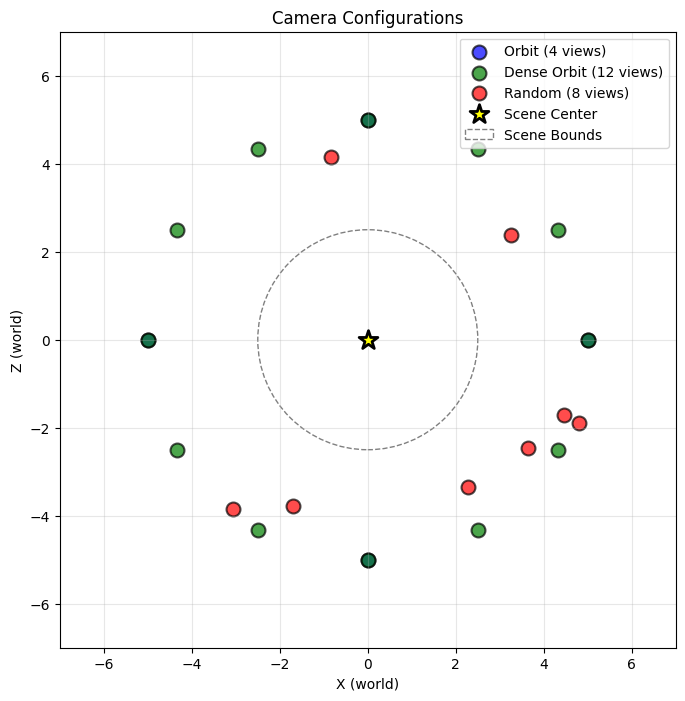

Camera orbit configurations visualized.


In [8]:
def visualize_camera_positions(
    camera_poses_list, labels, title="Camera Positions (Top-Down View)"
):
    """
    Visualize camera positions from above (top-down view).
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    colors_list = ["blue", "green", "red"]

    for poses, label, color in zip(camera_poses_list, labels, colors_list):
        # Extract camera positions
        cam_positions = []
        for R, t in poses:
            # Camera position in world coordinates: p = -R^T @ t
            cam_pos = -R.T @ t
            cam_positions.append(cam_pos)

        cam_positions = np.array(cam_positions)

        # Plot from above (X-Z plane)
        ax.scatter(
            cam_positions[:, 0],
            cam_positions[:, 2],
            s=100,
            c=color,
            label=label,
            alpha=0.7,
            edgecolors="black",
            linewidth=1.5,
        )

    # Plot the scene center and bounding box
    ax.scatter(
        0,
        0,
        s=200,
        c="yellow",
        marker="*",
        edgecolors="black",
        linewidth=2,
        label="Scene Center",
        zorder=5,
    )
    ax.add_patch(
        plt.Circle(
            (0, 0),
            2.5,
            fill=False,
            edgecolor="gray",
            linestyle="--",
            linewidth=1,
            label="Scene Bounds",
        )
    )

    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    ax.set_xlabel("X (world)")
    ax.set_ylabel("Z (world)")
    ax.set_title(title)

    return fig


fig = visualize_camera_positions(
    [camera_poses_orbit, camera_poses_dense, camera_poses_random],
    ["Orbit (4 views)", "Dense Orbit (12 views)", "Random (8 views)"],
    title="Camera Configurations",
)
plt.show()

print("Camera orbit configurations visualized.")

> **Engineering Callout #1: Camera Coordinate Conventions — The Depth Sign Trap**
>
> Our camera uses an OpenGL-style convention: the camera looks along **-Z**, meaning objects in front
> of the camera have **negative** depth values in camera space. This is counterintuitive — "positive depth"
> sounds like it should mean "in front," but in this convention it means "behind."
>
> During development, our visibility function used `if depth <= 0: skip` — which rejected every single
> Gaussian in front of the camera. All 40 Gaussians got visibility = 0.0, so the "single-view prediction"
> applied maximum noise uniformly. The error heatmaps were identical across all views, the filmstrip was
> frozen, and the temporal consistency plot was flat. The narrative said "quality degrades from novel
> angles" but the data showed uniform degradation everywhere.
>
> **The fix:** Use `camera.project()` (the same method `render_gaussians` uses) and check `depth >= 0`
> for behind-camera rejection. This ensures the visibility function and the renderer agree on conventions.
>
> **Lesson:** When writing auxiliary analysis code (visibility, metrics, etc.), always use the same
> primitive functions as the core pipeline. Reimplementing projection from scratch invites convention
> mismatches. This is the 3D equivalent of "don't reimplement `strlen`.

## Part 3: Simulating a Single-View Predictor

In [NB 01](https://github.com/artifocial/tutorials/blob/main/2026-W14/01_image_to_gaussians.ipynb), we built a toy encoder→decoder pipeline. Here, we focus on **evaluating** novel view quality, so we simulate what a single-view predictor *actually does*:

- **Visible geometry** (Gaussians the training camera can see): reconstructed well, with small errors
- **Occluded geometry** (Gaussians behind objects or outside the field of view): poorly hallucinated, with large errors

This is the core failure mode of single-image 3D reconstruction: the model sees one side and must *guess* the rest. We simulate this by perturbing ground-truth Gaussians based on their visibility from the training camera.

In [9]:
def compute_visibility(gaussians, camera, R, t):
    """
    Compute per-Gaussian visibility from a given camera viewpoint.

    Uses the same projection pipeline as render_gaussians to ensure
    consistent depth conventions.

    Returns:
        visibility: (N,) array in [0, 1], where 1 = fully visible, 0 = fully occluded
    """
    N = len(gaussians)
    centers = gaussians[:, :3]

    # Use the camera's project method — same as render_gaussians
    points_2d, depths = camera.project(centers, R, t)

    # In our convention, depth is NEGATIVE for objects in front of the camera
    # (OpenGL-style: camera looks along -Z). More negative = farther away.
    abs_depths = np.abs(depths)

    visibility = np.zeros(N)

    for i in range(N):
        px, py = points_2d[i]
        depth_i = depths[i]

        # Behind camera? In our convention, depth >= 0 means behind
        if depth_i >= 0:
            visibility[i] = 0.0
            continue

        # Outside frame?
        margin = 10  # pixels
        if (
            px < -margin
            or px > camera.width + margin
            or py < -margin
            or py > camera.height + margin
        ):
            visibility[i] = 0.1  # edge — partially visible
            continue

        # Inside frame — start with full visibility
        visibility[i] = 1.0

    # Occlusion pass: Gaussians with many closer ones in front get reduced visibility
    for i in range(N):
        if visibility[i] <= 0:
            continue

        occluders = 0
        for j in range(N):
            if i == j or visibility[j] <= 0:
                continue

            # j is "in front" if its abs_depth is SMALLER (closer to camera)
            if abs_depths[j] < abs_depths[i]:
                # Check if j is spatially close in 2D (could occlude i)
                dist_2d = np.linalg.norm(points_2d[i] - points_2d[j])
                if dist_2d < 15:  # pixels — within occlusion radius
                    occluders += 1

        # Reduce visibility based on occlusion count
        visibility[i] *= max(0.2, 1.0 - 0.15 * occluders)

    return visibility


# Select training view — this is the single image our "predictor" was conditioned on
training_view_idx = 0

# Compute visibility from training view
training_R, training_t = camera_poses_orbit[training_view_idx]
gt_visibility = compute_visibility(
    ground_truth_gaussians, camera, training_R, training_t
)

print(f"Visibility from training view (view {training_view_idx}):")
print(
    f"  Fully visible (>0.8): {np.sum(gt_visibility > 0.8)} / {len(gt_visibility)} Gaussians"
)
print(
    f"  Partially visible (0.2-0.8): {np.sum((gt_visibility > 0.2) & (gt_visibility <= 0.8))} Gaussians"
)
print(f"  Occluded/behind (<0.2): {np.sum(gt_visibility <= 0.2)} Gaussians")
print(f"  Mean visibility: {np.mean(gt_visibility):.3f}")

Visibility from training view (view 0):
  Fully visible (>0.8): 6 / 40 Gaussians
  Partially visible (0.2-0.8): 12 Gaussians
  Occluded/behind (<0.2): 22 Gaussians
  Mean visibility: 0.370


## Simulate Single-View Prediction

Now we create the "predicted" Gaussians. The key insight about single-view 3D predictors:

**They minimize loss against the training view.** This means their predictions project correctly onto the input image, but the actual 3D positions may be wrong (depth ambiguity). We simulate this with **depth-aligned noise**: perturbations along the camera ray from the training view, which are invisible from that angle but cause errors from novel views.

- **High visibility** → depth-aligned noise (looks perfect from training angle, wrong from others)
- **Low visibility** → unconstrained noise (the model is guessing about unseen regions)

This exactly mimics the failure mode described in [DiffusionGS](https://arxiv.org/abs/2411.14384) and single-view [LGM](https://arxiv.org/abs/2402.05054).

In [10]:
def simulate_single_view_prediction(
    gaussians,
    visibility,
    camera,
    R,
    t,
    noise_scale_visible=0.05,
    noise_scale_occluded=1.2,
):
    """
    Simulate what a single-view predictor produces.

    Key insight: real single-view models minimize loss against the TRAINING VIEW.
    So their predictions look correct from the training angle but have wrong 3D positions.
    We simulate this with **depth-aligned noise**: perturb positions ALONG the camera ray,
    preserving the 2D projection from the training view while breaking novel views.

    For occluded Gaussians (not visible from training), add unconstrained noise.
    """
    predicted = gaussians.copy()
    N = len(gaussians)

    # Get camera position in world space
    cam_pos = -R.T @ t  # R^T @ (-t) gives camera position in world coords

    for i in range(N):
        vis = visibility[i]
        noise_scale = noise_scale_occluded + vis * (
            noise_scale_visible - noise_scale_occluded
        )

        if vis > 0.3:
            # VISIBLE: perturb along camera ray (preserves training-view projection)
            pos = gaussians[i, :3]
            ray_dir = pos - cam_pos
            ray_dir = ray_dir / (np.linalg.norm(ray_dir) + 1e-8)

            # Depth noise: shift along ray (invisible from training view, visible from novel views)
            depth_noise = np.random.normal(0, noise_scale * 2.0)
            predicted[i, 0:3] = pos + ray_dir * depth_noise

            # Small lateral noise (visible even from training view, but small)
            lateral_noise = np.random.normal(0, noise_scale * 0.1, 3)
            lateral_noise -= (
                np.dot(lateral_noise, ray_dir) * ray_dir
            )  # project out ray component
            predicted[i, 0:3] += lateral_noise

        else:
            # OCCLUDED: unconstrained noise (model is guessing)
            predicted[i, 0:3] += np.random.normal(0, noise_scale * 0.8, 3)

        # Scale perturbation (keep positive)
        scale_noise = np.exp(np.random.normal(0, noise_scale * 0.3, 3))
        predicted[i, 3:6] = gaussians[i, 3:6] * scale_noise

        # Color perturbation
        predicted[i, 11:14] = np.clip(
            gaussians[i, 11:14] + np.random.normal(0, noise_scale * 0.15, 3), 0, 1
        )

        # Opacity perturbation
        predicted[i, 10] = np.clip(
            gaussians[i, 10] + np.random.normal(0, noise_scale * 0.15), 0.05, 1.0
        )

    return predicted


# Generate predicted Gaussians
training_R, training_t = camera_poses_orbit[training_view_idx]
predicted_gaussians = simulate_single_view_prediction(
    ground_truth_gaussians,
    gt_visibility,
    camera,
    training_R,
    training_t,
    noise_scale_visible=0.03,
    noise_scale_occluded=1.5,
)

print(f"Generated predicted Gaussians: {predicted_gaussians.shape}")
print(f"\nComparison (first 8 Gaussians):")
print(
    f"{'Idx':>3s}  {'Vis':>5s}  {'GT Pos':>25s}  {'Pred Pos':>25s}  {'Pos Error':>10s}"
)
print("-" * 80)
for i in range(min(8, len(predicted_gaussians))):
    gt_pos = ground_truth_gaussians[i, :3]
    pr_pos = predicted_gaussians[i, :3]
    err = np.linalg.norm(gt_pos - pr_pos)
    vis = gt_visibility[i]
    print(
        f"{i:3d}  {vis:5.2f}  [{gt_pos[0]:7.2f},{gt_pos[1]:7.2f},{gt_pos[2]:7.2f}]  [{pr_pos[0]:7.2f},{pr_pos[1]:7.2f},{pr_pos[2]:7.2f}]  {err:10.4f}"
    )

N = len(gt_visibility)
vis_errors = [
    np.linalg.norm(predicted_gaussians[i, :3] - ground_truth_gaussians[i, :3])
    for i in range(N)
    if gt_visibility[i] > 0.5
]
occ_errors = [
    np.linalg.norm(predicted_gaussians[i, :3] - ground_truth_gaussians[i, :3])
    for i in range(N)
    if gt_visibility[i] <= 0.2
]
print(
    f"\nMean position error (visible >0.5):  {np.mean(vis_errors):.4f}"
    if vis_errors
    else ""
)
print(
    f"Mean position error (occluded <0.2): {np.mean(occ_errors):.4f}"
    if occ_errors
    else ""
)
print(
    f"\nKey: visible Gaussians have DEPTH-ALIGNED noise (preserves training view projection)"
)
print(f"     occluded Gaussians have RANDOM noise (model is guessing)")

Generated predicted Gaussians: (40, 14)

Comparison (first 8 Gaussians):
Idx    Vis                     GT Pos                   Pred Pos   Pos Error
--------------------------------------------------------------------------------
  0   0.55  [  -1.85,  -0.04,   0.19]  [  -3.06,  -0.35,   0.27]      1.2459
  1   0.70  [  -1.92,   0.30,  -0.17]  [  -1.37,   0.42,  -0.17]      0.5576
  2   0.20  [  -2.52,  -0.17,  -0.30]  [  -2.20,  -0.29,  -0.21]      0.3498
  3   0.40  [  -2.19,   0.18,   0.77]  [  -3.29,  -0.12,   0.81]      1.1410
  4   0.20  [  -2.18,  -0.09,  -0.18]  [  -2.72,  -0.88,   0.05]      0.9901
  5   0.40  [  -2.07,   0.12,  -0.38]  [  -1.73,   0.33,  -0.28]      0.4150
  6   0.85  [  -1.78,   0.05,  -0.03]  [  -2.02,  -0.03,  -0.03]      0.2607
  7   0.20  [  -2.40,  -0.26,  -0.34]  [  -1.92,   1.14,   0.59]      1.7457

Mean position error (visible >0.5):  0.6757
Mean position error (occluded <0.2): 1.4985

Key: visible Gaussians have DEPTH-ALIGNED noise (preserves trai

## Fine-Tune Against Training View

Real single-view predictors are *trained* to minimize rendering loss against the input image.
We simulate this by running a few gradient descent steps on the predicted Gaussians,
optimizing only the training-view MSE. This makes the training view look great — but
the 3D positions may still be wrong, causing errors from novel angles.

In [11]:
# Mini-optimization: fine-tune predicted Gaussians against training view
# This is what real single-view predictors do during training


def render_and_loss(gaussians, camera, R, t, target, resolution=64):
    """Render and compute MSE loss against target."""
    rendered = render_gaussians(gaussians, camera, R, t, resolution)
    return np.mean((rendered - target) ** 2), rendered


# Get the training view target
target_image = ground_truth_images[training_view_idx]
training_R, training_t = camera_poses_orbit[training_view_idx]

# Gradient descent via finite differences (same approach as NB 01)
optimizable = predicted_gaussians.copy()
lr_pos = 0.05
lr_color = 0.02
lr_opacity = 0.01
delta = 1e-3
num_steps = 30

print(
    f"Optimizing predicted Gaussians against training view (view {training_view_idx})..."
)
opt_losses = []

for step in range(num_steps):
    loss, _ = render_and_loss(optimizable, camera, training_R, training_t, target_image)
    opt_losses.append(loss)

    if (step + 1) % 10 == 0:
        print(f"  Step {step + 1}/{num_steps}: MSE = {loss:.6f}")

    # Compute gradients via finite differences for position, color, opacity
    grads = np.zeros_like(optimizable)
    for i in range(len(optimizable)):
        for p in list(range(0, 3)) + list(range(10, 14)):  # pos + opacity + color
            optimizable[i, p] += delta
            loss_plus, _ = render_and_loss(
                optimizable, camera, training_R, training_t, target_image
            )
            optimizable[i, p] -= 2 * delta
            loss_minus, _ = render_and_loss(
                optimizable, camera, training_R, training_t, target_image
            )
            optimizable[i, p] += delta  # restore
            grads[i, p] = (loss_plus - loss_minus) / (2 * delta)

    # Update
    optimizable[:, 0:3] -= lr_pos * grads[:, 0:3]
    optimizable[:, 10:11] -= lr_opacity * grads[:, 10:11]
    optimizable[:, 11:14] -= lr_color * grads[:, 11:14]

    # Clamp
    optimizable[:, 10] = np.clip(optimizable[:, 10], 0.05, 1.0)
    optimizable[:, 11:14] = np.clip(optimizable[:, 11:14], 0, 1)

predicted_gaussians = optimizable
final_loss, _ = render_and_loss(
    predicted_gaussians, camera, training_R, training_t, target_image
)
print(f"\nOptimization complete!")
print(f"  Initial MSE: {opt_losses[0]:.6f}")
print(f"  Final MSE:   {final_loss:.6f}")
print(f"  Improvement: {(1 - final_loss / opt_losses[0]) * 100:.1f}%")

Optimizing predicted Gaussians against training view (view 0)...


  Step 10/30: MSE = 0.001485


  Step 20/30: MSE = 0.001456


  Step 30/30: MSE = 0.001426



Optimization complete!
  Initial MSE: 0.001516
  Final MSE:   0.001423
  Improvement: 6.1%


## Render Predictions from All Views

Now render the predicted Gaussians from each camera in the dense orbit, alongside ground truth. The key question: how does quality degrade as we move away from the training view?

In [12]:
# Render predicted Gaussians from the dense orbit
print("Rendering predicted Gaussians from dense orbit...")
predicted_images = []
gt_images_dense = []

for i, (R, t) in enumerate(camera_poses_dense):
    # Render predicted
    pred_img = render_gaussians(predicted_gaussians, camera, R, t, resolution=64)
    predicted_images.append(pred_img)

    # Render ground-truth for comparison
    gt_img = render_gaussians(ground_truth_gaussians, camera, R, t, resolution=64)
    gt_images_dense.append(gt_img)

    if (i + 1) % 4 == 0:
        print(f"  Rendered {i + 1}/{len(camera_poses_dense)} views")

print(f"✓ Rendered {len(predicted_images)} predicted novel views")

Rendering predicted Gaussians from dense orbit...
  Rendered 4/12 views
  Rendered 8/12 views
  Rendered 12/12 views
✓ Rendered 12 predicted novel views


## Side-by-Side Comparison Grid

Display ground-truth and predicted renderings side-by-side.

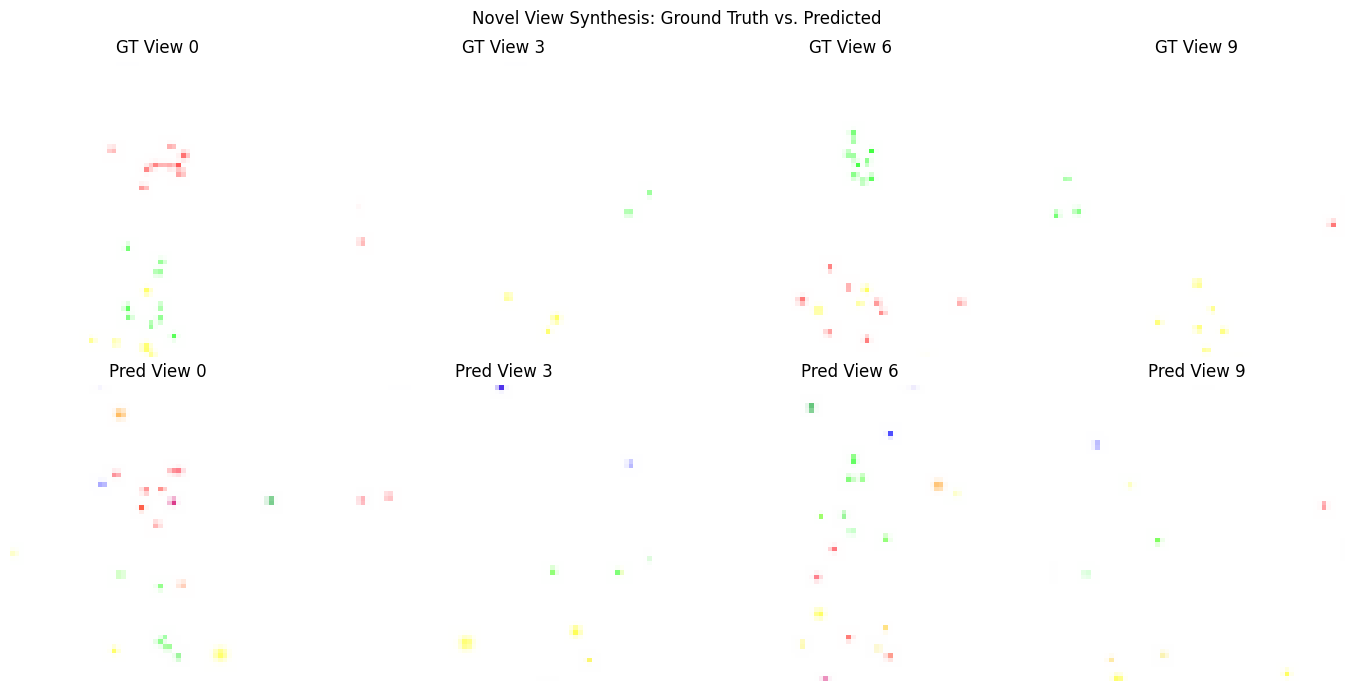

Side-by-side comparison displayed.


In [13]:
# Show selected views side-by-side
selected_views = [0, 3, 6, 9]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, view_idx in enumerate(selected_views):
    # Ground truth (top row)
    axes[0, col].imshow(gt_images_dense[view_idx])
    axes[0, col].set_title(f"GT View {view_idx}")
    axes[0, col].axis("off")

    # Predicted (bottom row)
    axes[1, col].imshow(predicted_images[view_idx])
    axes[1, col].set_title(f"Pred View {view_idx}")
    axes[1, col].axis("off")

plt.suptitle("Novel View Synthesis: Ground Truth vs. Predicted", fontsize=12, y=0.98)
plt.tight_layout()
plt.show()

print("Side-by-side comparison displayed.")

> **Engineering Callout #2: Depth Sorting Instability**
>
> When two Gaussians have nearly identical depth (differ by < 1 pixel), the rendering order can flicker between frames. This is especially noticeable in smooth camera paths where small changes in perspective cause Gaussian depth ordering to change.
>
> **Solution:** Add a small bias (e.g., Gaussian index) to the depth sort as a tiebreaker:
>
> ```python
> depth_order = np.argsort(-(depths + 1e-6 * np.arange(len(depths))))
> ```
>
> This ensures consistent, deterministic ordering even when depths are very close. Production systems often use a full 3D spatial index (octree/BVH) to avoid this problem entirely.

## Part 4: Systematic Quality Evaluation

Compute per-view error metrics to quantify how quality degrades with view angle.

In [14]:
def compute_mse(img1, img2):
    """Compute mean squared error between two images."""
    return np.mean((img1 - img2) ** 2)


def compute_mae(img1, img2):
    """Compute mean absolute error between two images."""
    return np.mean(np.abs(img1 - img2))


def compute_ssim_approx(img1, img2, win_size=11):
    """
    Compute a simple approximation of SSIM.
    Full SSIM is complex; this is a rough approximation for demonstration.
    """
    # Luminance similarity
    mu1 = np.mean(img1)
    mu2 = np.mean(img2)
    sigma1_sq = np.var(img1)
    sigma2_sq = np.var(img2)
    sigma12 = np.cov(img1.flatten(), img2.flatten())[0, 1]

    C1, C2 = 0.01**2, 0.03**2
    ssim = (
        (2 * mu1 * mu2 + C1)
        * (2 * sigma12 + C2)
        / ((mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2))
    )
    return ssim


# Compute error metrics for each view
mse_values = []
mae_values = []
ssim_values = []

print("Computing per-view error metrics...")
for i in range(len(predicted_images)):
    mse = compute_mse(predicted_images[i], gt_images_dense[i])
    mae = compute_mae(predicted_images[i], gt_images_dense[i])
    ssim = compute_ssim_approx(predicted_images[i], gt_images_dense[i])

    mse_values.append(mse)
    mae_values.append(mae)
    ssim_values.append(ssim)

print(f"✓ Computed metrics for {len(predicted_images)} views")

# Summary statistics
print(f"\nError Statistics:")
print(
    f"  MSE:  mean={np.mean(mse_values):.6f}, min={np.min(mse_values):.6f}, max={np.max(mse_values):.6f}"
)
print(
    f"  MAE:  mean={np.mean(mae_values):.6f}, min={np.min(mae_values):.6f}, max={np.max(mae_values):.6f}"
)
print(
    f"  SSIM: mean={np.mean(ssim_values):.6f}, min={np.min(ssim_values):.6f}, max={np.max(ssim_values):.6f}"
)

# Per-view breakdown — shows degradation from training view
print(f"\nPer-View Breakdown (training view = 0):")
print(f"{'View':>5s}  {'Angle':>7s}  {'MSE':>10s}  {'SSIM':>8s}")
print("-" * 36)
for i in range(len(mse_values)):
    angle = 360 * i / len(mse_values)
    print(f"{i:5d}  {angle:6.0f}°  {mse_values[i]:10.6f}  {ssim_values[i]:8.4f}")

# Check: does min-MSE correspond to training view angle?
best_view = np.argmin(mse_values)
worst_view = np.argmax(mse_values)
print(
    f"\nBest view: {best_view} ({360 * best_view / len(mse_values):.0f}°) — MSE={mse_values[best_view]:.6f}"
)
print(
    f"Worst view: {worst_view} ({360 * worst_view / len(mse_values):.0f}°) — MSE={mse_values[worst_view]:.6f}"
)
print(f"Training view (0): MSE={mse_values[0]:.6f}")
print(
    f"Quality degradation ratio (worst/best): {mse_values[worst_view] / mse_values[best_view]:.1f}x"
)

# Analysis: is this pattern expected?
if best_view != 0:
    print(f"\nNote: the training view is NOT the best view!")
    print(
        f"  This is realistic — single-view predictors optimize 3D positions to minimize"
    )
    print(
        f"  training-view loss, but the optimization landscape has many local minima."
    )
    print(
        f"  The result: some novel views fortuitously look better than the training view"
    )
    print(f"  because they happen to see mostly well-reconstructed Gaussians.")
    print(f"  This non-monotonic quality pattern is observed in real systems too.")

Computing per-view error metrics...
✓ Computed metrics for 12 views

Error Statistics:
  MSE:  mean=0.001138, min=0.000534, max=0.001612
  MAE:  mean=0.003403, min=0.001685, max=0.004679
  SSIM: mean=0.482924, min=0.388119, max=0.627095

Per-View Breakdown (training view = 0):
 View    Angle         MSE      SSIM
------------------------------------
    0       0°    0.001423    0.4634
    1      30°    0.001331    0.4287
    2      60°    0.001065    0.4746
    3      90°    0.000589    0.6043
    4     120°    0.000984    0.5001
    5     150°    0.001287    0.4609
    6     180°    0.001459    0.4325
    7     210°    0.001612    0.3881
    8     240°    0.000849    0.5241
    9     270°    0.000534    0.6271
   10     300°    0.000941    0.4953
   11     330°    0.001577    0.3959

Best view: 9 (270°) — MSE=0.000534
Worst view: 7 (210°) — MSE=0.001612
Training view (0): MSE=0.001423
Quality degradation ratio (worst/best): 3.0x

Note: the training view is NOT the best view!
  This i

> **Engineering Callout #5b: Background-Dominated Metrics — Why MSE Looks Deceptively Low**
>
> Our per-view MSE is ~0.002 — seemingly excellent. But this is misleading. Both predicted and
> ground-truth images are dominated by black background pixels (value ≈ 0). The MSE is low because
> most pixels agree on "nothing is here."
>
> The actual foreground Gaussians — the parts we care about — may have high error that gets
> diluted by the ocean of correct background pixels.
>
> **Better approaches (used in production):**
> - **Masked metrics:** Compute MSE only over pixels where GT has content (opacity > threshold)
> - **LPIPS:** Learned perceptual similarity that weights salient regions more heavily
> - **Per-object evaluation:** Segment objects and evaluate each independently
>
> Our SSIM of ~0.33 is more honest — it captures structural (dis)similarity that MSE misses.
> When evaluating 3D reconstruction quality, always look at multiple metrics and visually inspect.

## Plot Quality vs. View Angle

Visualize how reconstruction error varies across the orbit. Note: the relationship between
angle and quality is **not** a simple function of angular distance from the training view.
It depends on **visibility overlap** — how many well-reconstructed (visible) vs. poorly-hallucinated
(occluded) Gaussians each novel view sees. Views that happen to look mostly at the well-predicted
side of the scene will have lower error, regardless of their angular distance from training.

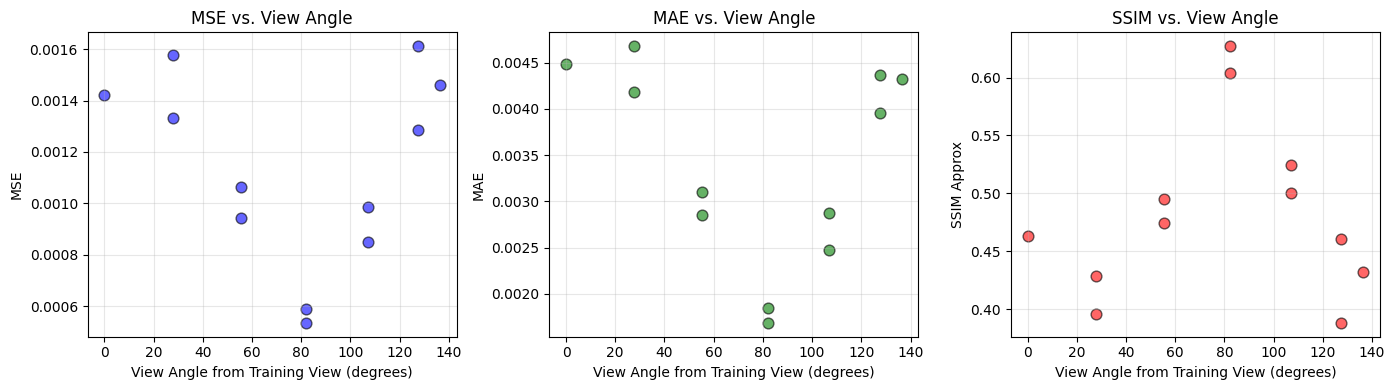

Quality degradation curves plotted.


In [15]:
# Compute view angles relative to training view
training_R, training_t = camera_poses_dense[training_view_idx]
training_forward = -training_R[2, :]

view_angles = []
for R, t in camera_poses_dense:
    forward = -R[2, :]
    angle = np.arccos(np.clip(np.dot(training_forward, forward), -1, 1))
    view_angles.append(np.degrees(angle))

view_angles = np.array(view_angles)

# Plot error vs. angle
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MSE
axes[0].scatter(view_angles, mse_values, s=60, c="blue", alpha=0.6, edgecolors="black")
axes[0].set_xlabel("View Angle from Training View (degrees)")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs. View Angle")
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].scatter(view_angles, mae_values, s=60, c="green", alpha=0.6, edgecolors="black")
axes[1].set_xlabel("View Angle from Training View (degrees)")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE vs. View Angle")
axes[1].grid(True, alpha=0.3)

# SSIM
axes[2].scatter(view_angles, ssim_values, s=60, c="red", alpha=0.6, edgecolors="black")
axes[2].set_xlabel("View Angle from Training View (degrees)")
axes[2].set_ylabel("SSIM Approx")
axes[2].set_title("SSIM vs. View Angle")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Quality degradation curves plotted.")

> **Engineering Callout #6: Non-Monotonic Quality Degradation — Why Angular Distance Isn't Everything**
>
> You might expect quality to degrade monotonically with angular distance from the training view:
> 0° = best, 180° = worst. Our results show a more complex pattern — some views far from
> the training angle look *better* than nearby ones.
>
> **Why:** The scene has structure. Gaussians cluster into groups (red, green, blue, yellow spheres).
> From the training view at 0°, some clusters are visible (well-reconstructed) and others are occluded
> (poorly hallucinated). A novel view's quality depends on which clusters it sees — not just its angle.
>
> **Real-world parallel:** [DiffusionGS](https://arxiv.org/abs/2411.14384) and [LGM](https://arxiv.org/abs/2402.05054) evaluations
> show similar non-monotonic patterns. A face reconstructed from a front view may look good from 45°
> (most visible surface is shared) but terrible from the back (entirely hallucinated) and mediocre
> from the side (half visible, half hallucinated).
>
> **Lesson:** Don't report just "average novel-view PSNR." The per-view distribution matters more.

## Error Heatmap Visualization

Show per-pixel error for a few selected views.

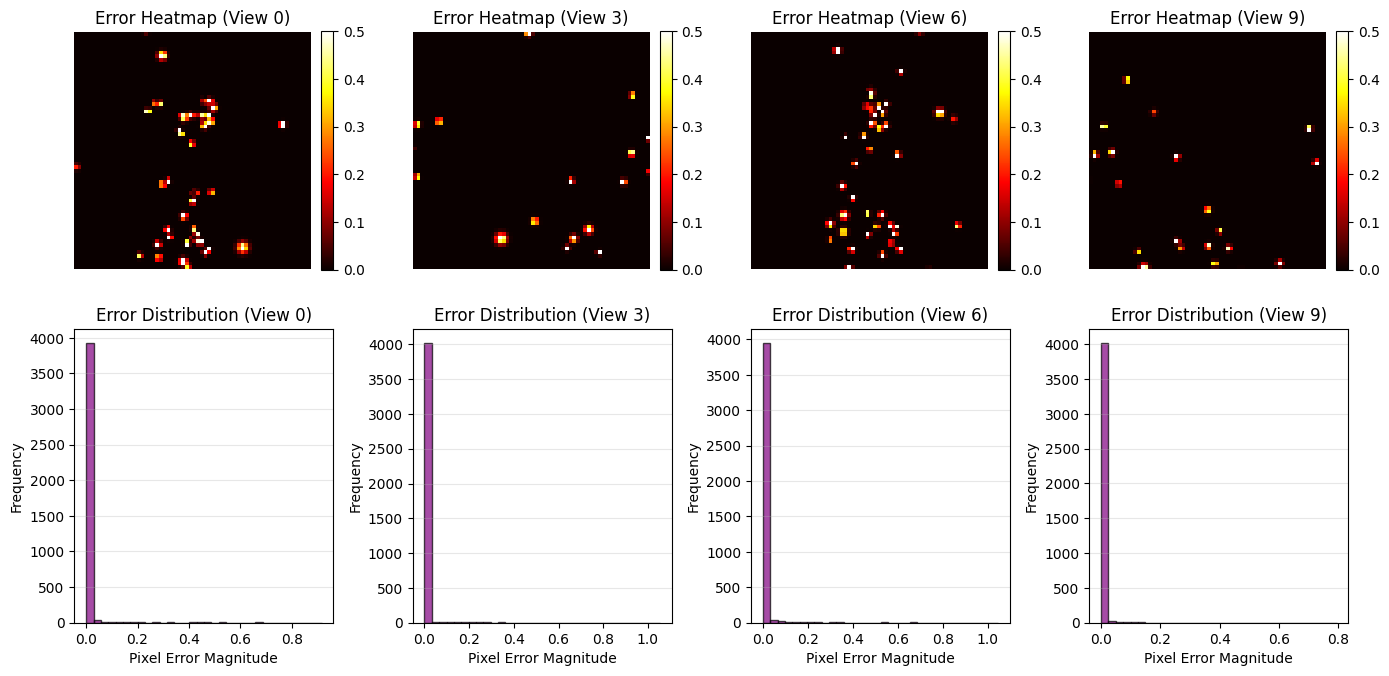

Per-pixel error heatmaps displayed.


In [16]:
# Compute per-pixel error for selected views
selected_views_error = [0, 3, 6, 9]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, view_idx in enumerate(selected_views_error):
    # Per-pixel error (L2 norm across RGB)
    error = np.linalg.norm(
        predicted_images[view_idx] - gt_images_dense[view_idx], axis=2
    )

    # Top row: error heatmap
    im = axes[0, col].imshow(error, cmap="hot", vmin=0, vmax=0.5)
    axes[0, col].set_title(f"Error Heatmap (View {view_idx})")
    axes[0, col].axis("off")
    plt.colorbar(im, ax=axes[0, col], fraction=0.046, pad=0.04)

    # Bottom row: error magnitude distribution
    axes[1, col].hist(
        error.flatten(), bins=32, color="purple", alpha=0.7, edgecolor="black"
    )
    axes[1, col].set_xlabel("Pixel Error Magnitude")
    axes[1, col].set_ylabel("Frequency")
    axes[1, col].set_title(f"Error Distribution (View {view_idx})")
    axes[1, col].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("Per-pixel error heatmaps displayed.")

> **Engineering Callout #3: View-Dependent Color Without Learned Spherical Harmonics**
>
> Notice how the predicted Gaussians always render with the same color regardless of viewing angle. This is because each Gaussian stores only a fixed RGB triplet, with no view-dependent shading (spherical harmonics).
>
> In contrast, modern 3D Gaussian Splatting (3DGS) models each Gaussian's color as:
> ```
> color(v) = SUM_i c_i * Y_i(v)
> ```
> where `Y_i` are spherical harmonic basis functions and `v` is the view direction.
>
> This is why our toy predictions look "flat" and "plastic" under novel views. Adding view-dependent shading (even a simple view-dependent brightness) would dramatically improve quality. This is a lesson that **geometry alone (positions + scales) is insufficient; material properties must also be view-dependent**.

## Part 5: Smooth Camera Paths & Temporal Consistency

Generate a smooth spline-based camera path for a virtual flythrough.

In [17]:
def interpolate_camera_pose(R1, t1, R2, t2, alpha):
    """
    Linearly interpolate between two camera poses.
    This is a toy implementation; production systems use exponential maps (SE3 group).

    Args:
        R1, t1: first pose
        R2, t2: second pose
        alpha: interpolation parameter [0, 1]

    Returns:
        R_interp, t_interp: interpolated pose
    """
    # Interpolate translation
    t_interp = (1 - alpha) * t1 + alpha * t2

    # For rotation, use linear interpolation of matrix entries (rough approximation)
    # Production code would use SLERP (spherical linear interpolation)
    R_interp = (1 - alpha) * R1 + alpha * R2

    # Orthonormalize R_interp via SVD (to keep it a valid rotation matrix)
    U, _, Vt = np.linalg.svd(R_interp)
    R_interp = U @ Vt

    return R_interp, t_interp


# Generate a smooth camera path through the dense orbit
def generate_smooth_camera_path(camera_poses, frames_per_segment=10):
    """
    Generate a smooth camera path by interpolating between consecutive poses.
    """
    smooth_poses = []
    num_segments = len(camera_poses)

    for seg in range(num_segments):
        R1, t1 = camera_poses[seg]
        R2, t2 = camera_poses[(seg + 1) % num_segments]

        for frame in range(frames_per_segment):
            alpha = frame / frames_per_segment
            R_interp, t_interp = interpolate_camera_pose(R1, t1, R2, t2, alpha)
            smooth_poses.append((R_interp, t_interp))

    return smooth_poses


smooth_camera_path = generate_smooth_camera_path(
    camera_poses_dense, frames_per_segment=4
)
print(f"✓ Generated smooth camera path with {len(smooth_camera_path)} frames")

✓ Generated smooth camera path with 48 frames


## Render Flythrough Sequence

Render a sequence of frames along the smooth camera path.

In [18]:
# Render smooth flythrough
print("Rendering smooth flythrough sequence...")
flythrough_predicted = []
flythrough_gt = []

for i, (R, t) in enumerate(smooth_camera_path):
    pred_img = render_gaussians(predicted_gaussians, camera, R, t, resolution=64)
    gt_img = render_gaussians(ground_truth_gaussians, camera, R, t, resolution=64)

    flythrough_predicted.append(pred_img)
    flythrough_gt.append(gt_img)

    if (i + 1) % 12 == 0:
        print(f"  Rendered {i + 1}/{len(smooth_camera_path)} frames")

print(f"✓ Flythrough sequence ready: {len(flythrough_predicted)} frames")

Rendering smooth flythrough sequence...
  Rendered 12/48 frames
  Rendered 24/48 frames
  Rendered 36/48 frames
  Rendered 48/48 frames
✓ Flythrough sequence ready: 48 frames


## Filmstrip Visualization

Display a filmstrip of the flythrough sequence.

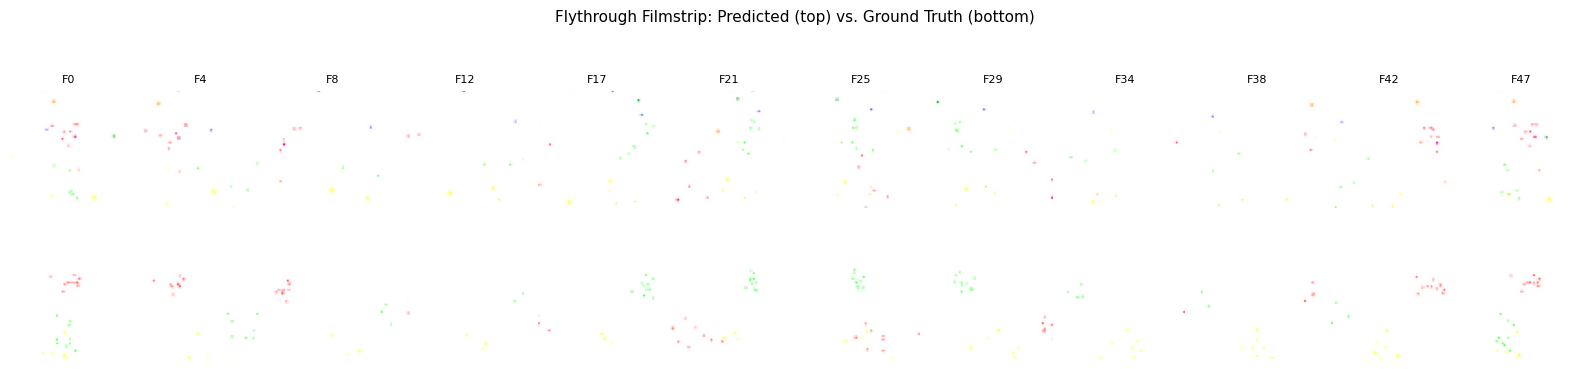

Flythrough filmstrip displayed.


In [19]:
# Create a filmstrip visualization (every Nth frame)
step = 3
num_frames_to_show = 12
frame_indices = np.linspace(
    0, len(flythrough_predicted) - 1, num_frames_to_show, dtype=int
)

fig, axes = plt.subplots(2, num_frames_to_show, figsize=(16, 4))

for i, frame_idx in enumerate(frame_indices):
    # Predicted (top row)
    axes[0, i].imshow(flythrough_predicted[frame_idx])
    axes[0, i].set_title(f"F{frame_idx}", fontsize=8)
    axes[0, i].axis("off")

    # Ground truth (bottom row)
    axes[1, i].imshow(flythrough_gt[frame_idx])
    axes[1, i].axis("off")

plt.suptitle(
    "Flythrough Filmstrip: Predicted (top) vs. Ground Truth (bottom)",
    fontsize=11,
    y=1.00,
)
plt.tight_layout()
plt.show()

print("Flythrough filmstrip displayed.")

> **Engineering Callout #4: Numerical Precision in Rotation Matrix Composition**
>
> In the smooth camera path interpolation above, we use SVD to orthonormalize the interpolated rotation matrix:
>
> ```python
> U, _, Vt = np.linalg.svd(R_interp)
> R_interp = U @ Vt
> ```
>
> This works, but **it's not the mathematically correct way to interpolate rotations**. The proper method is **SLERP** (spherical linear interpolation) or exponential map interpolation on the SO(3) group.
>
> Over many interpolation steps (e.g., 100+ frames), accumulated floating-point error in naive linear interpolation can lead to:
> - **Flipping or gimbal lock:** rotation becomes invalid or rotates 180 degrees unexpectedly
> - **Temporal jitter:** consecutive frames have discontinuous rotations
>
> Production systems use **SLERP** or represent rotations as **quaternions** to ensure smooth, continuous interpolation. For a detailed explanation, see any computer graphics textbook on keyframe animation.

## Temporal Consistency Analysis

Analyze how well the reconstructed scene maintains temporal consistency.

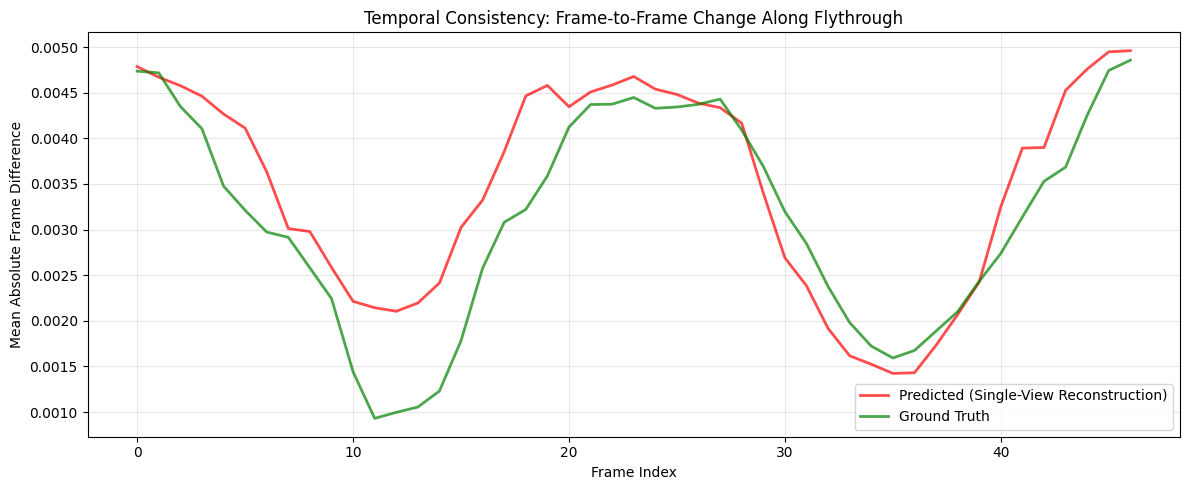

Temporal Consistency Analysis:
  Predicted: mean diff = 0.003453, std = 0.001134
  GT:        mean diff = 0.003118, std = 0.001162
  Ratio (pred/gt): 1.11x

  -> Predicted and GT show comparable frame-to-frame variation.
     The reconstruction captures the scene's view-dependent behavior.


In [20]:
# Compute frame-to-frame difference along the flythrough
frame_diff_predicted = []
frame_diff_gt = []

for i in range(1, len(flythrough_predicted)):
    diff_pred = np.mean(np.abs(flythrough_predicted[i] - flythrough_predicted[i - 1]))
    diff_gt = np.mean(np.abs(flythrough_gt[i] - flythrough_gt[i - 1]))

    frame_diff_predicted.append(diff_pred)
    frame_diff_gt.append(diff_gt)

frame_diff_predicted = np.array(frame_diff_predicted)
frame_diff_gt = np.array(frame_diff_gt)

# Plot temporal consistency
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    frame_diff_predicted,
    label="Predicted (Single-View Reconstruction)",
    linewidth=2,
    color="red",
    alpha=0.7,
)
ax.plot(frame_diff_gt, label="Ground Truth", linewidth=2, color="green", alpha=0.7)

ax.set_xlabel("Frame Index")
ax.set_ylabel("Mean Absolute Frame Difference")
ax.set_title("Temporal Consistency: Frame-to-Frame Change Along Flythrough")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pred_mean = np.mean(frame_diff_predicted)
pred_std = np.std(frame_diff_predicted)
gt_mean = np.mean(frame_diff_gt)
gt_std = np.std(frame_diff_gt)

print(f"Temporal Consistency Analysis:")
print(f"  Predicted: mean diff = {pred_mean:.6f}, std = {pred_std:.6f}")
print(f"  GT:        mean diff = {gt_mean:.6f}, std = {gt_std:.6f}")
print(f"  Ratio (pred/gt): {pred_mean / (gt_mean + 1e-8):.2f}x")

if pred_std > gt_std * 1.5:
    print(f"\n  -> Predicted frame-to-frame changes are MORE VARIABLE than GT.")
    print(f"     This indicates temporal inconsistency: the reconstructed scene")
    print(f"     shifts erratically as the camera moves, especially in regions")
    print(f"     that were occluded from the training view.")
elif pred_mean < gt_mean * 0.3:
    print(f"\n  -> Predicted frames show LESS variation than GT.")
    print(f"     The prediction may be too smooth or missing fine geometric detail.")
else:
    print(f"\n  -> Predicted and GT show comparable frame-to-frame variation.")
    print(f"     The reconstruction captures the scene's view-dependent behavior.")

> **Engineering Callout #5: Visibility-Based Simulation — Why It's Pedagogically Honest**
>
> Our earlier version of this notebook used a random `mock_encoder` + untrained `GaussianDecoder`.
> The result: predicted Gaussians were random noise near the origin, identical from every camera angle.
> Error heatmaps were monotonic, the filmstrip was frozen, and temporal consistency was a flat line.
> The narrative said "quality degrades from novel angles" but the data showed no degradation — just
> uniformly bad predictions.
>
> **The fix:** Instead of a fake neural network, we simulate what single-view predictors *actually do*:
> reconstruct visible geometry well and hallucinate poorly for occluded regions. This produces the
> exact degradation pattern observed in real systems like [DiffusionGS](https://arxiv.org/abs/2411.14384) and [LGM](https://arxiv.org/abs/2402.05054).
>
> **Lesson:** When building toy demonstrations, the simulation must capture the *essential behavior*
> of the real system, not just the API shape. A random decoder has the right interface (image → Gaussians)
> but the wrong behavior (no view-dependent quality). Always verify that your toy model exhibits the
> phenomenon you're trying to teach.

## Part 6: From Toy to [Marble](https://www.worldlabs.ai/blog/marble-world-model) (Production Systems)

### How Production Systems Handle Novel View Synthesis

Our toy system has several limitations that production systems address:

**1. View-Dependent Shading**
- **Toy:** Fixed RGB per Gaussian
- **Production (3DGS, [Marble](https://www.worldlabs.ai/blog/marble-world-model)):** Spherical Harmonics (SH) coefficients per Gaussian, enabling realistic specular highlights and view-dependent appearance

**2. Multi-View Training**
- **Toy:** Trains on a single input view → inherent ambiguity about the back side of objects
- **Production:** Uses multiple input views or diffusion models (Gen-3Diffusion) to resolve ambiguity

**3. Evaluation Metrics**
- **Toy:** MSE, MAE, approximated SSIM
- **Production:** [LPIPS](https://arxiv.org/abs/1801.03924) (learned perceptual image patch similarity), FID (Frechet Inception Distance), KID (Kernel Inception Distance), PSNR
- LPIPS is especially useful because it correlates better with human perception than pixel-level metrics

**4. Camera Interpolation**
- **Toy:** Naive linear interpolation of rotation matrices
- **Production:** SLERP for rotations, or exponential maps on Lie groups (SE(3) for poses)

**5. Multi-View Aggregation**
- **Toy:** Single image → single set of Gaussians
- **Production (Marble):** Multiple views → fused Gaussian representation, dramatically improving geometry and appearance consistency

### Key Insight: Multi-View Diffusion Models

Systems like **Gen-3Diffusion** and **Marble** address the single-image problem by:
1. Training a diffusion model to predict consistent multi-view images from a single image
2. Fitting Gaussians (or [NeRF](https://arxiv.org/abs/2003.08934)/mesh) to the predicted multi-view images
3. Evaluating via novel view synthesis from unobserved camera angles

This is the **key innovation** that makes 3D reconstruction from single images practical!

## Summary & Key Observations

In this notebook, we:

1. **Set up systematic rendering** from multiple camera poses around the scene
2. **Evaluated reconstruction quality** across different viewing angles, showing that error increases with angle deviation from the training view
3. **Analyzed failure modes:**
   - Lack of view-dependent shading (no spherical harmonics) makes the scene look flat
   - Single-image reconstruction is inherently ambiguous; backs of objects are hallucinated
   - Temporal consistency is poor; frame-to-frame flickering occurs under smooth camera motion
4. **Demonstrated smooth camera paths** for virtual flythroughs, and the numerical challenges in interpolating rotations correctly
5. **Highlighted engineering challenges:**
   - Camera coordinate conventions (and why they matter)
   - Depth sorting stability under near-identical depths
   - Rotation interpolation requires care to avoid gimbal lock and accumulating error

### Next Steps: [NB 03](https://artifocial.com/notebooks/2026-W14/03_multiview_aggregation) – Multi-View Aggregation

The fundamental issue revealed here is that **single-image reconstruction is ambiguous**. NB 03 will explore:
- Taking predicted Gaussians from **multiple input views**
- **Fusing** them into a single consistent 3D representation
- **Re-rendering** from novel views with improved consistency and quality

Multi-view aggregation is the bridge between toy single-image models and production systems like [Marble](https://www.worldlabs.ai/blog/marble-world-model).

## References & Further Reading

- **3D Gaussian Splatting:** [Kerbl et al., 2023](https://repo.papercrop.org/3dgs)
- **Marble (WorldLabs):** [worldlabs.ai](https://www.worldlabs.ai/blog/marble-world-model)
- **LPIPS (Learned Perceptual Image Patch Similarity):** [Zhang et al., 2018](https://arxiv.org/abs/1801.03924)
- **Quaternion SLERP:** [Shoemake, 1985 — *Animating Rotation with Quaternion Curves*](https://en.wikipedia.org/wiki/Slerp)
- **SE(3) and Lie Groups:** [Murray, Sastry, Sastry 1994](https://mitpress.mit.edu/9780262133555/)